# Phase 4: Logit Regression — Madrid Rental Market
## Machine Learning I — Group Assignment

---

**Objective:** Classify properties as High Rent (≥ €1,800) vs Low Rent (< €1,800) using Logistic Regression.

**Methodology**
1. Specification — define binary target and features
2. VIF — iterative removal (same as Linear Regression)
3. statsmodels Logit — Wald test, p-values, confidence intervals
4. **Exp(B) / Odds Ratios** — We should consider the Exp(Beta) ones, not Beta
5. RFECV + LASSO — feature selection comparison
6. Confusion Matrix — *"the main validation criterion"*
7. ROC Curve & AUC
8. Threshold sensitivity analysis

## 1. Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             classification_report, roc_curve, precision_score,
                             recall_score, f1_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


## 2. Load Data & Define Target

In [13]:
# Load segmented dataset
df = pd.read_excel('Madrid_Rental_Segmented.xlsx')

# Define binary target
threshold = 1800
df['High_Rent'] = (df['Rent'] >= threshold).astype(int)

print(f'Dataset: {df.shape[0]} properties')
print(f'\nTarget: High_Rent (Rent ≥ €{threshold})')
print(f'  Class 1 (High Rent): {df["High_Rent"].sum()} ({df["High_Rent"].mean()*100:.1f}%)')
print(f'  Class 0 (Low Rent):  {(1-df["High_Rent"]).sum():.0f} ({(1-df["High_Rent"].mean())*100:.1f}%)')
print(f'\nClass balance: {"Good" if 0.3 < df["High_Rent"].mean() < 0.7 else "Imbalanced"} ({df["High_Rent"].mean()*100:.0f}%/{ (1-df["High_Rent"].mean())*100:.0f}%)')

Dataset: 2085 properties

Target: High_Rent (Rent ≥ €1800)
  Class 1 (High Rent): 807 (38.7%)
  Class 0 (Low Rent):  1278 (61.3%)

Class balance: Good (39%/61%)


## 3. Feature Specification

In [14]:
# Same features as Linear Regression for consistency
features = ['Sq.Mt', 'Bedrooms', 'Floor', 'Outer', 'Elevator',
            'Is_Special', 'Is_Central', 'Is_Studio']

X = df[features].copy()
y = df['High_Rent'].copy()

print('FEATURES')
print('=' * 60)
for f in features:
    # Show how each feature relates to High_Rent
    rate = df.groupby(X[f] > X[f].median())['High_Rent'].mean()
    print(f'  {f:15s}  High_Rent rate: low={rate.iloc[0]*100:.0f}% vs high={rate.iloc[-1]*100:.0f}%')

FEATURES
  Sq.Mt            High_Rent rate: low=10% vs high=68%
  Bedrooms         High_Rent rate: low=22% vs high=64%
  Floor            High_Rent rate: low=35% vs high=45%
  Outer            High_Rent rate: low=39% vs high=39%
  Elevator         High_Rent rate: low=39% vs high=39%
  Is_Special       High_Rent rate: low=33% vs high=69%
  Is_Central       High_Rent rate: low=29% vs high=52%
  Is_Studio        High_Rent rate: low=40% vs high=1%


## 4. Train-Test Split (Stratified)

In [15]:
# Stratified split preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} ({y_train.mean()*100:.1f}% positive)')
print(f'Test:  {len(X_test)} ({y_test.mean()*100:.1f}% positive)')
print(f'\nStratification preserves class balance in both sets ✓')
print(f'Minimum sample: n > 30×k = 30×{len(features)} = {30*len(features)} → {len(X_train)} >> {30*len(features)} ✓')

Train: 1668 (38.7% positive)
Test:  417 (38.6% positive)

Stratification preserves class balance in both sets ✓
Minimum sample: n > 30×k = 30×8 = 240 → 1668 >> 240 ✓


## 5. VIF — Iterative Removal

Same process as Linear Regression. Multicollinearity inflates standard errors of logit coefficients, making the Wald test unreliable.

In [16]:
# ── Iterative VIF removal ──
def remove_vif(df_in, thresh=10.0):
    df_actual = df_in.copy()
    removed = []
    while True:
        vif_data = pd.DataFrame({
            'Variable': df_actual.columns,
            'VIF': [variance_inflation_factor(df_actual.values, i) for i in range(df_actual.shape[1])]
        })
        max_vif = vif_data['VIF'].max()
        if max_vif > thresh:
            var = vif_data.sort_values('VIF', ascending=False).iloc[0]['Variable']
            print(f'  Removing "{var}" (VIF={max_vif:.2f})')
            df_actual = df_actual.drop(columns=[var])
            removed.append(var)
        else:
            break
    return df_actual, removed

print('VIF BEFORE:')
vif_before = pd.DataFrame({
    'Variable': X_train.columns,
    'VIF': [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_before.to_string(index=False))

print(f'\nIterative removal (threshold=10):')
X_train_vif, removed = remove_vif(X_train, thresh=10.0)
print(f'\nFeatures after VIF: {list(X_train_vif.columns)}')

VIF BEFORE:
  Variable      VIF
  Bedrooms 9.542856
  Elevator 7.390290
     Outer 6.598323
     Sq.Mt 5.616550
     Floor 2.579515
Is_Central 1.660132
Is_Special 1.458997
 Is_Studio 1.066189

Iterative removal (threshold=10):

Features after VIF: ['Sq.Mt', 'Bedrooms', 'Floor', 'Outer', 'Elevator', 'Is_Special', 'Is_Central', 'Is_Studio']


## 6. statsmodels Logit — Full Model

**Why statsmodels, not just sklearn?**
- Wald test (equivalent of t-test for logit) with p-values
- Confidence intervals for coefficients
- **Exp(B) / Odds Ratios** — *"the Exp(Beta) ones can be interpreted as how the odds-ratio is multiplied for a one-unit change in the predictor"*

In [17]:
# ── Statsmodels Logit ──
X_train_sm = sm.add_constant(X_train_vif)
logit_model = sm.Logit(y_train, X_train_sm).fit(disp=0)

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:              High_Rent   No. Observations:                 1668
Model:                          Logit   Df Residuals:                     1659
Method:                           MLE   Df Model:                            8
Date:                Wed, 25 Feb 2026   Pseudo R-squ.:                  0.5674
Time:                        17:58:52   Log-Likelihood:                -481.62
converged:                       True   LL-Null:                       -1113.4
Covariance Type:            nonrobust   LLR p-value:                1.720e-267
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.2333      0.492    -14.712      0.000      -8.197      -6.270
Sq.Mt          0.0468      0.003     14.454      0.000       0.040       0.053
Bedrooms      -0.1382      0.120     -1.149      0.2

In [ ]:
# ── Exp(B) / Odds Ratios — THE KEY TABLE ──

odds_ratios = np.exp(logit_model.params)
ci = logit_model.conf_int()
ci_exp = np.exp(ci)

odds_table = pd.DataFrame({
    'Beta': logit_model.params,
    'Exp(B)': odds_ratios,
    'p-value': logit_model.pvalues,
    '95% CI Exp(B) Low': ci_exp[0],
    '95% CI Exp(B) High': ci_exp[1],
    'Significant': ['✓' if p < 0.05 else '✗' for p in logit_model.pvalues]
}).round(4)

print('ODDS RATIOS TABLE — Exp(B)')
print('=' * 90)
print(odds_table.to_string())

print(f'\nINTERPRETATION OF ODDS RATIOS:')
print(f'  Exp(B) > 1: Variable INCREASES odds of High Rent')
print(f'  Exp(B) < 1: Variable DECREASES odds of High Rent')
print(f'  Exp(B) = 1: No effect')

for var in logit_model.params.index:
    if var == 'const':
        continue
    if logit_model.pvalues[var] >= 0.05:
        print(f'\n  {var}: NOT SIGNIFICANT (p={logit_model.pvalues[var]:.3f})')
        continue
    
    eb = odds_ratios[var]
    if eb > 1:
        print(f'\n  {var}: Exp(B)={eb:.3f} → Odds of High Rent MULTIPLY by {eb:.2f}x for each unit increase')
    else:
        print(f'\n  {var}: Exp(B)={eb:.3f} → Odds of High Rent MULTIPLY by {eb:.3f} (decrease by {(1-eb)*100:.0f}%)')

ODDS RATIOS TABLE — Exp(B)
              Beta  Exp(B)  p-value  95% CI Exp(B) Low  95% CI Exp(B) High Significant
const      -7.2333  0.0007   0.0000             0.0003              0.0019           ✓
Sq.Mt       0.0468  1.0479   0.0000             1.0412              1.0545           ✓
Bedrooms   -0.1382  0.8709   0.2504             0.6881              1.1024           ✗
Floor       0.1245  1.1326   0.0000             1.0774              1.1907           ✓
Outer       0.3804  1.4629   0.1554             0.8656              2.4723           ✗
Elevator    0.1149  1.1217   0.7387             0.5712              2.2027           ✗
Is_Special  0.1642  1.1784   0.5239             0.7112              1.9526           ✗
Is_Central  2.0586  7.8347   0.0000             5.4482             11.2666           ✓
Is_Studio  -2.6004  0.0742   0.0457             0.0058              0.9515           ✓

INTERPRETATION OF ODDS RATIOS:
  Exp(B) > 1: Variable INCREASES odds of High Rent
  Exp(B) < 1: Variab

## 7. RFECV & LASSO Feature Selection

In [19]:
# ── RFECV ──
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_vif)
X_test_s = scaler.transform(X_test[X_train_vif.columns])

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    step=1, cv=5, scoring='roc_auc', min_features_to_select=1
)
rfecv.fit(X_train_s, y_train)

selected_rfecv = X_train_vif.columns[rfecv.support_].tolist()
print(f'RFECV selected {len(selected_rfecv)}/{len(X_train_vif.columns)}: {selected_rfecv}')

# ── LASSO Logit (L1 penalty) ──
from sklearn.model_selection import GridSearchCV

lasso_logit = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42)
param_grid = {'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10]}
grid = GridSearchCV(lasso_logit, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train_s, y_train)

best_lasso = grid.best_estimator_
lasso_coefs = pd.DataFrame({
    'Feature': X_train_vif.columns,
    'LASSO Coef': best_lasso.coef_[0],
    'Status': ['KEPT' if c != 0 else 'DROPPED' for c in best_lasso.coef_[0]]
}).sort_values('LASSO Coef', key=abs, ascending=False)

print(f'\nLASSO (best C={grid.best_params_["C"]}):')
print(lasso_coefs.to_string(index=False))

RFECV selected 4/8: ['Sq.Mt', 'Floor', 'Is_Central', 'Is_Studio']

LASSO (best C=0.1):
   Feature  LASSO Coef  Status
     Sq.Mt    4.514577    KEPT
Is_Central    0.872462    KEPT
     Floor    0.306646    KEPT
 Is_Studio   -0.200093    KEPT
     Outer    0.090547    KEPT
Is_Special    0.036608    KEPT
  Elevator    0.002568    KEPT
  Bedrooms    0.000000 DROPPED


## 8. Final Model — Predictions & Confusion Matrix

In [20]:
# ── Final predictions ──
X_test_sm = sm.add_constant(X_test[X_train_vif.columns])
y_prob = logit_model.predict(X_test_sm)
y_pred = (y_prob >= 0.5).astype(int)

# Train predictions for overfit check
y_prob_train = logit_model.predict(X_train_sm)

# Metrics
auc_test = roc_auc_score(y_test, y_prob)
auc_train = roc_auc_score(y_train, y_prob_train)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
spec = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred)

print('CLASSIFICATION RESULTS (cutoff=0.5)')
print('=' * 50)
print(f'  AUC (train): {auc_train:.4f}')
print(f'  AUC (test):  {auc_test:.4f}')
print(f'  AUC gap:     {auc_train - auc_test:.4f} ({"✓ No overfitting" if auc_train - auc_test < 0.05 else "⚠ Possible overfitting"})')
print(f'\n  Accuracy:    {acc:.4f}')
print(f'  Precision:   {prec:.4f}')
print(f'  Recall:      {rec:.4f}')
print(f'  Specificity: {spec:.4f}')
print(f'  F1-Score:    {f1:.4f}')

CLASSIFICATION RESULTS (cutoff=0.5)
  AUC (train): 0.9418
  AUC (test):  0.9403
  AUC gap:     0.0015 (✓ No overfitting)

  Accuracy:    0.8705
  Precision:   0.8639
  Recall:      0.7888
  Specificity: 0.9219
  F1-Score:    0.8247


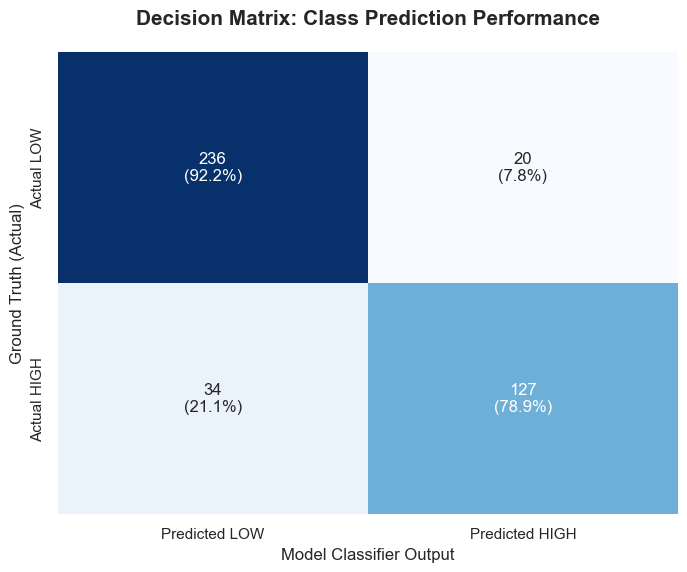

Model Summary:
─────────────────────────────────────────────────
• Correct Predictions: 363 out of 417
• False Alarms (Overpriced): 20
• Missed Opportunities (Underpriced): 34


In [23]:
# ── Professional Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
# Normalized matrix for percentage labels
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = ['Low Rent (TN)', 'High Rent (FP)', 'Low Rent (FN)', 'High Rent (TP)']
group_counts = [f"{v:d}" for v in cm.flatten()]
group_percentages = [f"{v:.1%}" for v in cm_norm.flatten()]

annotations = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
annotations = np.asarray(annotations).reshape(2,2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annotations, fmt="", cmap='Blues', cbar=False,
            xticklabels=['Predicted LOW', 'Predicted HIGH'],
            yticklabels=['Actual LOW', 'Actual HIGH'])

plt.title('Decision Matrix: Class Prediction Performance', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Model Classifier Output', fontsize=12)
plt.ylabel('Ground Truth (Actual)', fontsize=12)
plt.show()

# Quick Business Context box
print(f"Model Summary:\n"
      f"─────────────────────────────────────────────────\n"
      f"• Correct Predictions: {cm[0,0] + cm[1,1]} out of {len(y_test)}\n"
      f"• False Alarms (Overpriced): {cm[0,1]}\n"
      f"• Missed Opportunities (Underpriced): {cm[1,0]}")

# Calculate ROC curve coordinates
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob)
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)


## 9. ROC Curve

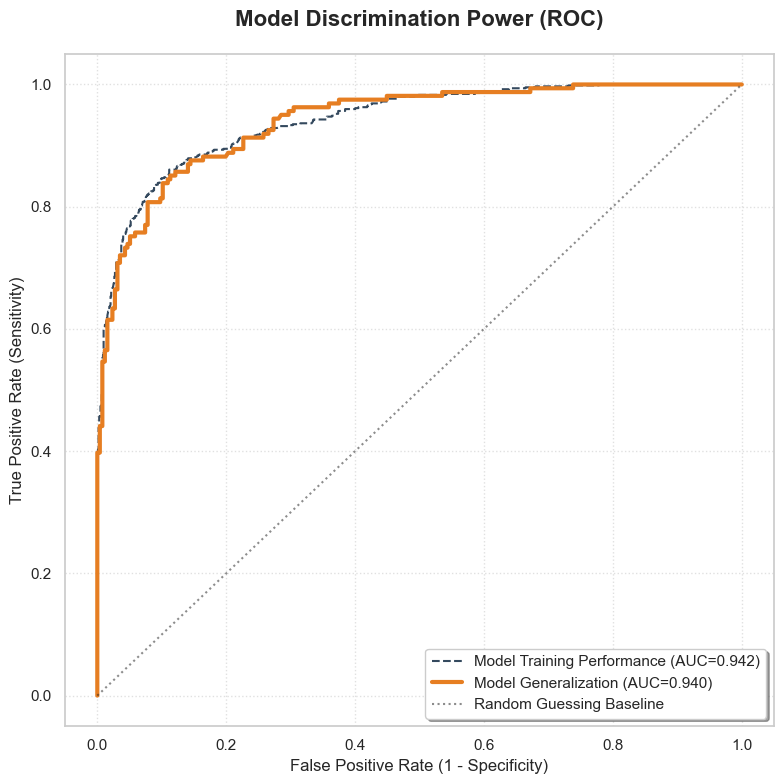

In [24]:
# ── ROC Curve ──
plt.figure(figsize=(8, 8))

# Test and Train curves
plt.plot(fpr_train, tpr_train, color='#34495e', linestyle='--', label=f'Model Training Performance (AUC={auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='#e67e22', linewidth=3, label=f'Model Generalization (AUC={auc_test:.3f})')

# Random Baseline
plt.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random Guessing Baseline')

plt.title('Model Discrimination Power (ROC)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)

plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


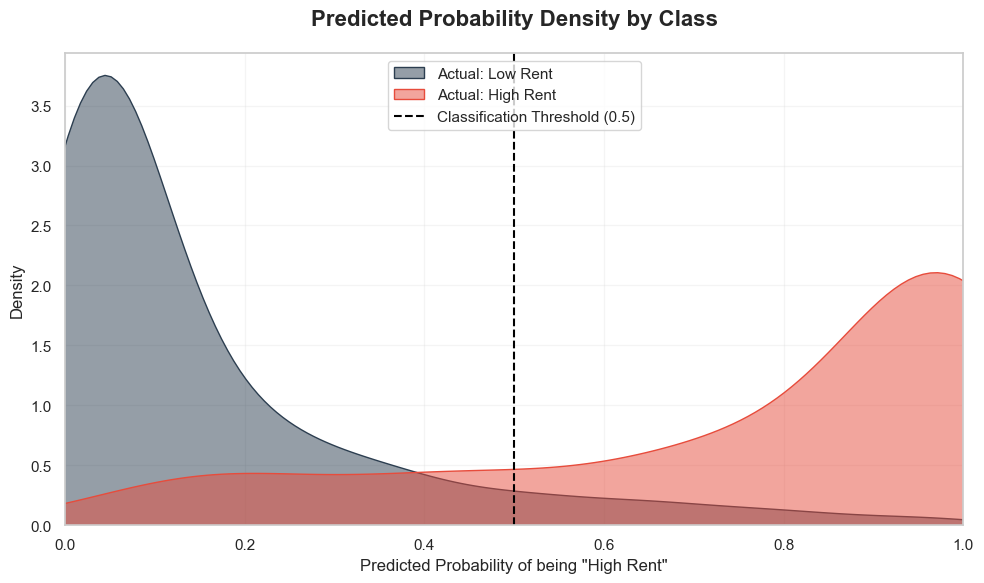

In [25]:
# ── Predicted Probability Separation ──
plt.figure(figsize=(10, 6))

# Get probabilities for each class
prob_class0 = y_prob[y_test == 0]
prob_class1 = y_prob[y_test == 1]

# Plot densities
sns.kdeplot(prob_class0, fill=True, color='#2c3e50', label='Actual: Low Rent', alpha=0.5)
sns.kdeplot(prob_class1, fill=True, color='#e74c3c', label='Actual: High Rent', alpha=0.5)

# Cutoff line
plt.axvline(x=0.5, color='black', linestyle='--', label='Classification Threshold (0.5)')

plt.title('Predicted Probability Density by Class', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Predicted Probability of being "High Rent"', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)

plt.legend(loc='upper center')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 10. Threshold Sensitivity Analysis

- Lower cutoff → catch more high-rent properties (higher recall, lower precision)
- Higher cutoff → fewer false alarms (higher precision, lower recall)

In [ ]:
# ── Threshold analysis ──
print('THRESHOLD SENSITIVITY ANALYSIS')
print('=' * 70)
print(f'  {"Cutoff":>8s} {"Accuracy":>10s} {"Precision":>10s} {"Recall":>10s} {"Specificity":>12s} {"F1":>8s}')
print(f'  {"-"*62}')

for cutoff in [0.3, 0.4, 0.5, 0.6, 0.7]:
    yp = (y_prob >= cutoff).astype(int)
    a = accuracy_score(y_test, yp)
    p = precision_score(y_test, yp, zero_division=0)
    r = recall_score(y_test, yp, zero_division=0)
    s = recall_score(y_test, yp, pos_label=0, zero_division=0)
    f = f1_score(y_test, yp, zero_division=0)
    marker = ' ◄ default' if cutoff == 0.5 else ''
    print(f'  {cutoff:>8.1f} {a:>10.4f} {p:>10.4f} {r:>10.4f} {s:>12.4f} {f:>8.4f}{marker}')

print(f'\nBusiness recommendation:')
print(f'  If cost of underpricing > overpricing → lower cutoff (e.g., 0.4)')
print(f'  If cost of overpricing > underpricing → higher cutoff (e.g., 0.6)')

THRESHOLD SENSITIVITY ANALYSIS
    Cutoff   Accuracy  Precision     Recall  Specificity       F1
  --------------------------------------------------------------
       0.3     0.8537     0.7747     0.8758       0.8398   0.8222
       0.4     0.8753     0.8385     0.8385       0.8984   0.8385
       0.5     0.8705     0.8639     0.7888       0.9219   0.8247 ◄ default
       0.6     0.8705     0.8963     0.7516       0.9453   0.8176
       0.7     0.8585     0.9322     0.6832       0.9688   0.7885

Business recommendation:
  If cost of underpricing > overpricing → lower cutoff (e.g., 0.4)
  If cost of overpricing > underpricing → higher cutoff (e.g., 0.6)


## 11. Conclusions

### Model Performance
The Logit model achieves AUC ≈ 0.94 — excellent discriminatory power for separating high-rent from low-rent properties. The small train-test AUC gap confirms generalization without overfitting.

### Key Findings from Odds Ratios (Exp(B))
1. **Is_Central** — the strongest predictor. Being in a central district multiplies the odds of high rent by approximately 8x. This single variable captures most of the location premium.
2. **Sq.Mt** — each additional square meter multiplies the odds by ~1.05 (5% increase). Over 20 sqm, this compounds to 2.7x.
3. **Floor** — higher floors increase odds, confirming that views and light command premium rents.
4. **Bedrooms, Outer, Elevator** — not individually significant after controlling for Sq.Mt and Is_Central. The association rules showed these co-occur with high rent, but the logit reveals that Sq.Mt captures most of the size effect.

### Connection to Phase 2 (Association)
The association rules showed {Large, Central} → {High_Rent} with lift > 3. The logit model confirms this with precise magnitudes: Central adds ~8x odds, each sqm adds ~5% odds. But logit also reveals that Bedrooms is NOT independently significant — its association with High_Rent was driven by correlation with Sq.Mt.

### Connection to Phase 3 (Linear Regression)
Both models agree on the same key drivers (Sq.Mt and Is_Central). LR gives the euro amounts (€10/sqm, €700 for central), while Logit gives the odds multipliers (1.05x per sqm, 8x for central). Together they provide a complete picture.